<a href="https://colab.research.google.com/github/AryaBagmare/EEG-Band-and-spectral-analysis/blob/main/eeg1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [8]:
!pip install mne


In [9]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [10]:
file_path = "/content/eeg1.edf"
raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw.info)

Extracting EDF parameters from /content/eeg1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [11]:
# Bandpass filter (0.5–40 Hz)
raw.filter(0.5, 40)

# Notch filter (50 Hz powerline noise)
raw.notch_filter(50)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1057 samples (6.606 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

<RawEDF | eeg1.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>

In [12]:
data, times = raw.get_data(return_times=True)

# Select one channel (e.g., first channel)
channel_data = data[0]
sfreq = raw.info['sfreq']   # sampling frequency

In [13]:
n = len(channel_data)
fft_vals = np.fft.fft(channel_data)
fft_vals = np.abs(fft_vals) / n

freqs = np.fft.fftfreq(n, 1/sfreq)

In [14]:
positive_freqs = freqs[:n // 2]
positive_fft = fft_vals[:n // 2]

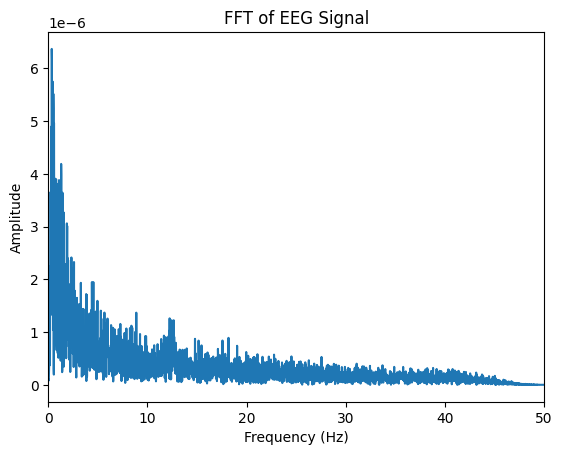

In [15]:
plt.figure()
plt.plot(positive_freqs, positive_fft)
plt.title("FFT of EEG Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 50)
plt.show()

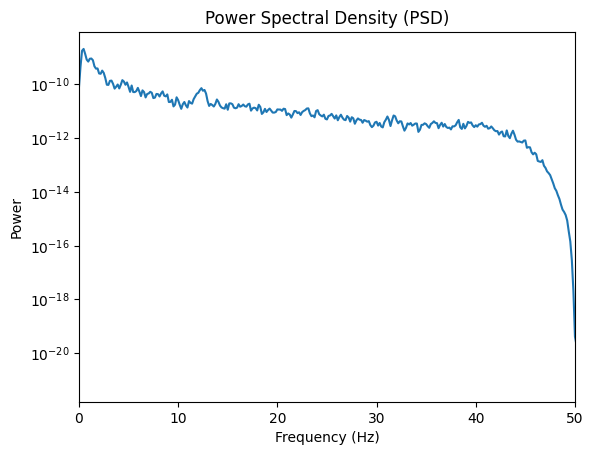

In [16]:
freqs_psd, psd = welch(channel_data, sfreq, nperseg=1024)

plt.figure()
plt.semilogy(freqs_psd, psd)
plt.title("Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim(0, 50)
plt.show()

In [17]:
def bandpower(data, sf, band):
    low, high = band
    freqs, psd = welch(data, sf, nperseg=1024)
    idx = np.logical_and(freqs >= low, freqs <= high)
    from scipy.integrate import trapezoid
    return trapezoid(psd[idx], freqs[idx])
delta = bandpower(channel_data, sfreq, (0.5, 4))
theta = bandpower(channel_data, sfreq, (4, 8))
alpha = bandpower(channel_data, sfreq, (8, 13))
beta  = bandpower(channel_data, sfreq, (13, 30))

print("Band Powers:")
print(f"Delta: {delta}")
print(f"Theta: {theta}")
print(f"Alpha: {alpha}")
print(f"Beta: {beta}")

Band Powers:
Delta: 1.2376784805244402e-09
Theta: 2.492254388479565e-10
Alpha: 1.5741640525646623e-10
Beta: 1.6728128112268128e-10


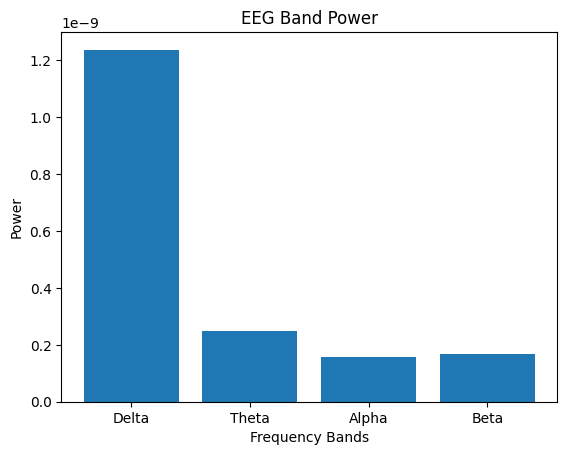

In [18]:
bands = ['Delta', 'Theta', 'Alpha', 'Beta']
values = [delta, theta, alpha, beta]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(bands, values)
plt.title("EEG Band Power")
plt.xlabel("Frequency Bands")
plt.ylabel("Power")
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Get data
data = raw.get_data()
sfreq = raw.info['sfreq']
channel_data = data[0]   # first channel

# -----------------------------
# Bandpass filter function
# -----------------------------
def bandpass(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# -----------------------------
# Extract bands
# -----------------------------
delta = bandpass(channel_data, 0.5, 4, sfreq)
theta = bandpass(channel_data, 4, 8, sfreq)
alpha = bandpass(channel_data, 8, 13, sfreq)
beta  = bandpass(channel_data, 13, 30, sfreq)

times = np.arange(len(channel_data)) / sfreq

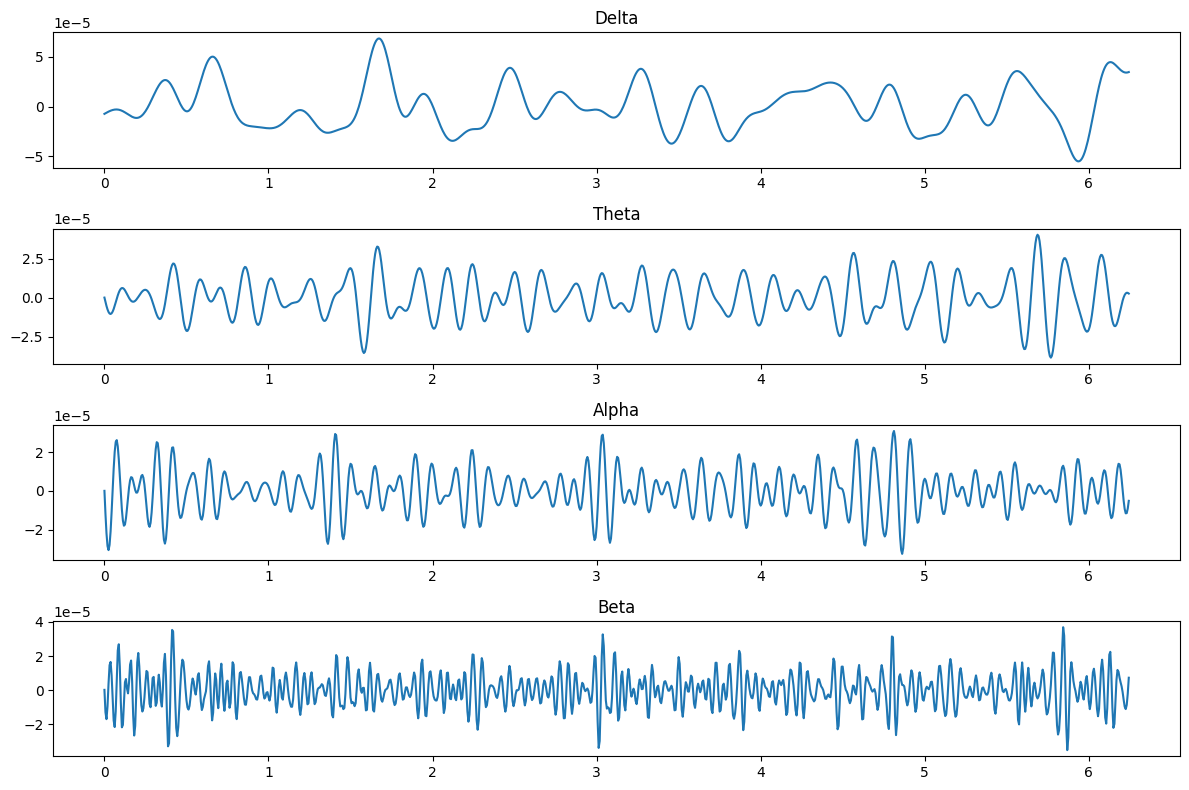

In [22]:
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(times[:1000], delta[:1000])
plt.title("Delta")

plt.subplot(4,1,2)
plt.plot(times[:1000], theta[:1000])
plt.title("Theta")

plt.subplot(4,1,3)
plt.plot(times[:1000], alpha[:1000])
plt.title("Alpha")

plt.subplot(4,1,4)
plt.plot(times[:1000], beta[:1000])
plt.title("Beta")

plt.tight_layout()
plt.show()